In [2]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
from utils.logger import get_logger
_logs = get_logger(__name__)

In [3]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import os
from glob import glob

In [4]:
ft_dir = os.getenv("FEATURES_DATA")
ft_glob = glob(os.path.join(ft_dir, '**/*.parquet'), 
               recursive = True)
df = dd.read_parquet(ft_glob).compute().reset_index()

# Sampling in Python

+ There are different packages that allow sampling.
+ A practical approach is to use pandas/Dask sampling methods.

## Random Sampling

+ Sample n rows from a dataframe with [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).

```
DataFrame.sample(
    n=None, frac=None, replace=False, weights=None, 
    random_state=None, axis=None, ignore_index=False
    )
```

In [5]:
df.sample(n = 5)

,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1
171067,KEY,2006-07-13,35.049999,35.150002,34.57,34.619999,23.882761,1091400.0,KEY.csv,2006,35.049999
324793,USLM,2015-09-03,51.840000,51.840000,51.84,51.840000,47.455235,400.0,USLM.csv,2015,51.950001
5222,AAON,2013-09-11,16.933332,17.020000,16.66,16.773333,15.931913,83100.0,AAON.csv,2013,16.940001
72687,CGEN,2018-04-13,4.500000,4.550000,4.40,4.500000,4.500000,123200.0,CGEN.csv,2018,4.500000
153097,JHS,2018-10-23,13.020000,13.080000,13.02,13.080000,12.154539,11200.0,JHS.csv,2018,13.040000


In [6]:
import random
random.seed(42)
sample_tickers = random.sample(df['ticker'].unique().tolist(), 30)
df = df[df['ticker'].isin(sample_tickers)]
simple_sample_dt = df.sample(frac = 0.1)
simple_sample_dt.shape, df.shape

((10599, 11), (105992, 11))

Look at the distribution of tickers.

<Axes: xlabel='ticker'>

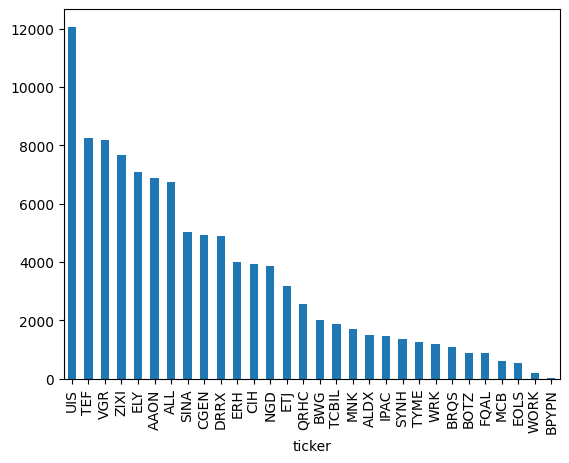

In [10]:
import matplotlib.pyplot as plt
df['ticker'].value_counts().plot(kind='bar')

<Axes: xlabel='ticker'>

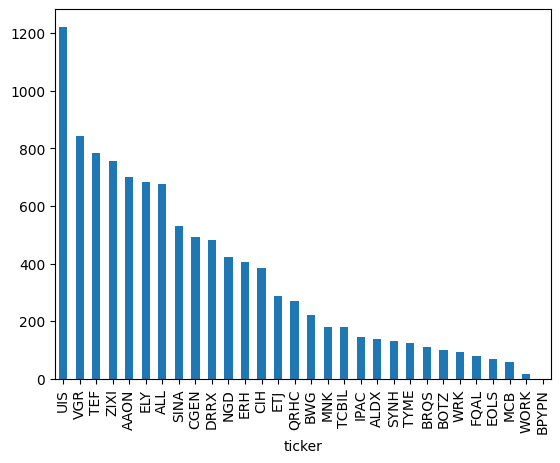

In [11]:
simple_sample_dt['ticker'].value_counts().plot(kind='bar')

## Stratified Sampling

+ Use `groupby()` and `.sample()` for stratified sampling.

<Axes: xlabel='ticker'>

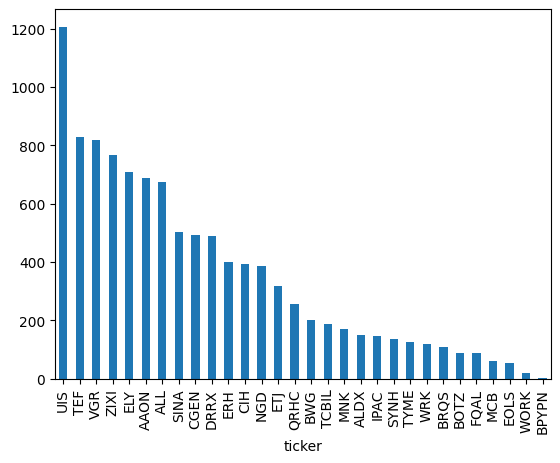

In [12]:
strat_sample_dt = df.groupby(['ticker']).sample(frac = 0.1)
strat_sample_dt['ticker'].value_counts().plot(kind='bar')

# Sampling in Dask

+ Stratified sampling in `dask` can be achieved with `groupby().apply()` and a lambda function.

C:\Users\ekadw\AppData\Local\Temp\ipykernel_21420\1783207470.py:4: UserWarning: `meta` is not specified, inferred from partial data.
Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result

  .apply(lambda x: x.sample(frac = 0.1))


<Axes: xlabel='ticker'>

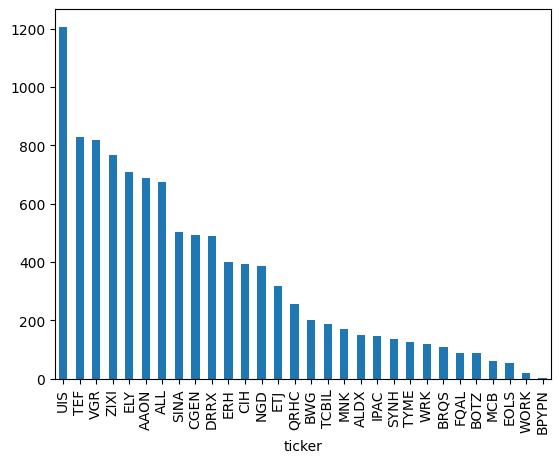

In [13]:
dd_dt = dd.read_parquet(ft_glob)
strat_sample_dd = (dd_dt
                      .groupby('ticker', group_keys=False)
                      .apply(lambda x: x.sample(frac = 0.1))
                      .compute()
                      .reset_index())
strat_sample_dd[strat_sample_dd['ticker'].isin(sample_tickers)]['ticker'].value_counts().plot(kind='bar')